Based on https://github.com/XENON1T/CEvNS/blob/master/notebooks/B8_neutrino_spectrum.ipynb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json as js
from tqdm import tqdm

import pickle

from scipy.interpolate import interp1d

In [2]:
params = {
    'xtick.direction' : 'in',
    'ytick.direction' : 'in',
    'font.family' : 'serif',
    'font.size' : 15,
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    'xtick.major.size' : 8,
    'ytick.major.size' : 8,
    'xtick.major.width' : 1.5,
    'ytick.major.width' : 1.5,
    'axes.linewidth' : 1.5,
    'axes.labelsize' : 17
}

plt.rcParams.update(params)
# plt.rc('text', usetex=True)

In [3]:
""" IN SI UNIT """
""" Reduced Planck Constant in J·s """
HBAR = 1.054571800E-34
""" Speed of Light in m/s """
C = 2.99792458E8
""" Avogaro's Number in 1/mol """
A_V = 6.022140857E23
""" Charge of Electron in C """
CH_E = 1.6021766208E-19

""" keV in J """
KEV = 1e3 * CH_E
""" GeV in J """
GEV = 1e9 * CH_E

In [4]:
Xe124 = {
    'Type'		: 'Xe124',
    'MassNum'	: 124,
    'AtomicNum'	: 54,
    'Mass'		: 123.905893,
    'Spin'		: 0,
    'Fraction'	: 9.52E-4
}

Xe126 = {
    'Type'		: 'Xe126',
    'MassNum'	: 126,
    'AtomicNum'	: 54,
    'Mass'		: 125.904274,
    'Spin'		: 0,
    'Fraction'	: 8.90E-4
}

Xe128 = {
    'Type'		: 'Xe128',
    'MassNum'	: 128,
    'AtomicNum'	: 54,
    'Mass'		: 127.9035313,
    'Spin'		: 0,
    'Fraction'	: 0.019102
}

Xe129 = {
    'Type'		: 'Xe129',
    'MassNum'	: 129,
    'AtomicNum'	: 54,
    'Mass'		: 128.9047794,
    'Spin'		: 0.5,
    'Fraction'	: 0.264006
}

Xe130 = {
    'Type'		: 'Xe130',
    'MassNum'	: 130,
    'AtomicNum'	: 54,
    'Mass'		: 129.9035080,
    'Spin'		: 0,
    'Fraction'	: 0.040710
}

Xe131 = {
    'Type'		: 'Xe131',
    'MassNum'	: 131,
    'AtomicNum'	: 54,
    'Mass'		: 130.9050824,
    'Spin'		: 1.5,
    'Fraction'	: 0.212324
}

Xe132 = {
    'Type'		: 'Xe132',
    'MassNum'	: 132,
    'AtomicNum'	: 54,
    'Mass'		: 131.9041535,
    'Spin'		: 0,
    'Fraction'	: 0.269086
}

Xe134 = {
    'Type'		: 'Xe134',
    'MassNum'	: 134,
    'AtomicNum'	: 54,
    'Mass'		: 133.9053945,
    'Spin'		: 0,
    'Fraction'	: 0.104357
}

Xe136 = {
    'Type'		: 'Xe136',
    'MassNum'	: 136,
    'AtomicNum'	: 54,
    'Mass'		: 135.907219,
    'Spin'		: 0,
    'Fraction'	: 0.088573
}

ATOM_TABLE = {
    'Xe124'	: Xe124,
    'Xe126'	: Xe126,
    'Xe128'	: Xe128,
    'Xe129'	: Xe129,
    'Xe130'	: Xe130,
    'Xe131'	: Xe131,
    'Xe132'	: Xe132,
    'Xe134'	: Xe134,
    'Xe136'	: Xe136
}

In [5]:
GeV = 1.0
MeV = GeV / 1e3
keV = GeV / 1e6
eV = GeV / 1e9

# GeV ^ -1
m = 1.0 / (HBAR * C / GEV) / GeV
cm = m / 1e2
km = m * 1e3
mm = m / 1e3
um = m / 1e6
nm = m / 1e9
pm = m / 1e12
fm = m / 1e15

# GeV
kg = 1.0 * C**2 / GEV * GeV
ton = kg * 1e3
g = kg * 1e-3

# GeV ^ -1
sec = 1.0 * C * m
dy = 24.0 * 3600.0 * sec
yr = 365.0 * dy

# Fermi's const
Gf = 1.1663787e-5 / GeV**2

# Neutron mass
mn = 0.9314940954 * GeV

# Mixing angle
sin2the = 0.2223

# Standard model CEvNS spectrum

In [6]:
from scipy.special import spherical_jn
from scipy.integrate import quad

class TARGET(object):
    def __init__(self, atom, pure = False):
        super(TARGET, self).__init__()
        self.target = atom
        self.spin = atom["Spin"]
        self.abund = 1 if pure else atom["Fraction"]
        self.A = atom["MassNum"]
        self.Z = atom["AtomicNum"]
        self.N = self.A - self.Z
        self.mass = atom["Mass"] * mn
        self.Qw = self.N - (1 - 4.0 * sin2the) * self.Z
    
    def TransMoment(self, Er):
        return np.sqrt(2 * self.mass * Er)
    
    def MinNeutrinoEnergy(self, Er):
        return (Er + np.sqrt(Er**2 + 2 * self.mass * Er)) / 2.0
    
    def MaxRecoilEnergy(self, Ev):
        return 2 * Ev**2 / (self.mass + 2 * Ev)
    
    def FormFactor(self, q):
        if q == 0:
            return 1.0
        a = 0.52 * fm
        c = (1.23 * self.A**(1.0/3.0) - 0.6) * fm
        s = 0.9 * fm
        rn = np.sqrt(c**2 + 7.0 / 3.0 * np.pi**2 * a**2 - 5 * s**2)
        qrn = q * rn
        return (3 * spherical_jn(1, qrn) / qrn)**2 * np.exp(- (q * s)**2)

    #cross-section as given in equation 2 page 9 of CEvNS paper
    def dXsecdErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            return 0
        q = self.TransMoment(Er)
        return Gf**2 / 4.0 / np.pi * self.Qw**2 * self.mass * (1 - self.mass * Er / 2 / Ev**2) * self.FormFactor(q)
    
    def Integrator(self, func, xmin, xmax):
        result, foo = quad(func, xmin, xmax)
        return result
    
    #modified by Riya
    #Assuming mono-energetic neutrinos
    #it is returning events/(ton*keV*Fluence) where fluence is flux integrated over time and so units of cm^(-2)
    def dRatedErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            #print(".")
            return 0
        # f(_ev)=F*delta(_ev), so no-integration
        return self.dXsecdErecoil(Er, Ev) * self.abund / self.mass * (cm**(-2))

In [7]:
NaturalXe = [TARGET(ATOM_TABLE["Xe124"], pure = False),
          TARGET(ATOM_TABLE["Xe126"], pure = False),
          TARGET(ATOM_TABLE["Xe128"], pure = False),
          TARGET(ATOM_TABLE["Xe129"], pure = False),
          TARGET(ATOM_TABLE["Xe130"], pure = False),
          TARGET(ATOM_TABLE["Xe131"], pure = False),
          TARGET(ATOM_TABLE["Xe132"], pure = False),
          TARGET(ATOM_TABLE["Xe134"], pure = False),
          TARGET(ATOM_TABLE["Xe136"], pure = False)]

Number of target atoms:

In [8]:
N_T = sum([xe.abund/xe.mass for xe in NaturalXe]) * ton
N_T

4.588020143230578e+27

Checking effect of non-standard interactions

In [8]:
er = np.linspace(0.2, 100, 40)*keV
def EpsToMultiplier(eps_e_u, eps_e_d):
    smi = 0
    nsi = 0
    
    Qn_sm = -1
    Qn_ns = Qn_sm + 2 * eps_e_u + 4 * eps_e_d
    Qp_sm = 1 - 4.0 * sin2the
    Qp_ns = Qp_sm + 4 * eps_e_u + 2 * eps_e_d
    
    for xe in NaturalXe:
        smi += (xe.N * Qn_sm + xe.Z * Qp_sm) ** 2 * xe.abund
        nsi += (xe.N * Qn_ns + xe.Z * Qp_ns) ** 2 * xe.abund
        
    return nsi / smi

eps_e_d, eps_e_u = np.meshgrid(np.linspace(-1, 1, 30), np.linspace(-1, 1, 30))
eps_e_d = eps_e_d.ravel()
eps_e_u = eps_e_u.ravel()
multiplier = np.zeros_like(eps_e_d)

for i in tqdm(range(len(eps_e_d))):
    #print(i, EpsToMultiplier(eps_e_u[i], eps_e_d[i]))
    multiplier[i] = (5+EpsToMultiplier(eps_e_u[i], eps_e_d[i]))/6

multiplier = multiplier.reshape((30,30))
eps_e_d = eps_e_d.reshape((30,30))
eps_e_u = eps_e_u.reshape((30,30))

100%|██████████| 900/900 [00:00<00:00, 41100.03it/s]


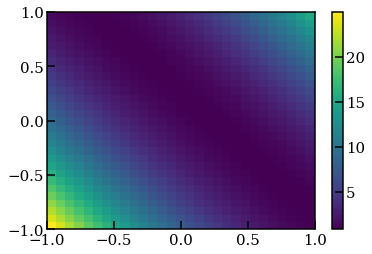

In [9]:
fig, ax = plt.subplots()
plt.pcolor(eps_e_d, eps_e_u, multiplier)
#plt.contour(eps_e_d, eps_e_u, multiplier, levels=[0,2])
#plt.plot(cf_x, cf_y1)
#plt.plot(cf_x, cf_y2)
plt.colorbar()
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.show()


In [10]:
#contour lines of xenon1t for these terms
cf_x = np.linspace(-1, 1, 30)
xenon1t_low_x1 = -1
xenon1t_low_y1 = 0.88
xenon1t_low_x2 = 0.75
xenon1t_low_y2 = -0.997

cf_slope1 = (xenon1t_low_y1 - xenon1t_low_y2)/(xenon1t_low_x1 - xenon1t_low_x2)
cf_y1 = cf_slope1*(cf_x-xenon1t_low_x1)+xenon1t_low_y1

xenon1t_high_x1 = -0.33
xenon1t_high_y1 = 0.997
xenon1t_high_x2 = 1
xenon1t_high_y2 = -0.5

cf_slope2 = (xenon1t_high_y1 - xenon1t_high_y2)/(xenon1t_high_x1 - xenon1t_high_x2)
cf_y2 = cf_slope2*(cf_x-xenon1t_high_x1)+xenon1t_high_y1

In [11]:
eps_e_u = []
eps_e_d = []
for i in range(0,30):
    eps_e_u.append(np.linspace(max(-1,cf_y1[i]), min(cf_y2[i],1), 10))
    eps_e_d.append(cf_x[i])

In [12]:
multiplier = np.zeros_like(eps_e_u)
eps_e_d_plot = []
for i in tqdm(range(len(eps_e_d))):
    for j in range(0, np.shape(eps_e_u)[1]):
        #print(i, EpsToMultiplier(eps_e_u[i], eps_e_d[i]))
        multiplier[i][j] = (5+EpsToMultiplier(eps_e_d[i], eps_e_u[i][j]))/6
    eps_e_d_plot.append(np.zeros(10) + eps_e_d[i])

100%|██████████| 30/30 [00:00<00:00, 3019.95it/s]


In [13]:
modification_low = np.min(multiplier)

In [14]:
modification_up = np.max(multiplier)

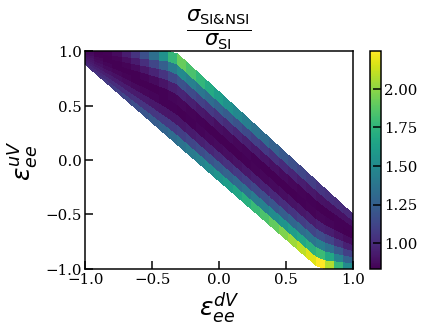

In [15]:
plt.pcolor(eps_e_d_plot, eps_e_u, multiplier)
plt.colorbar()

plt.xlabel(r'$\epsilon_{ee}^{dV}$', fontsize=25)
plt.ylabel(r'$\epsilon_{ee}^{uV}$', fontsize=25)
plt.title(r"$\frac{\sigma_\mathrm{SI&NSI}}{\sigma_\mathrm{SI}}$", fontsize=30)
plt.show()

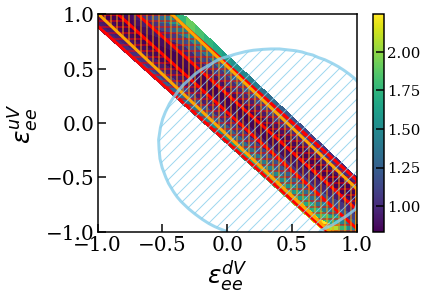

In [291]:
'''
# Data from COHERENT arxiv: 2003.10630
X = np.linspace(-1, 1, 50)
x, y = 0, 1

data = np.array([[-0.9639934533551555, 0.9699248120300752], [0.6628477905073649, -0.853383458646616]])
CsI_2017_lower = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.4108019639934535, 0.9849624060150377], [0.9410801963993451, -0.5375939849624058]])
CsI_2017_upper = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.9770867430441899, 0.868421052631579], [0.7086743044189852, -0.9323308270676689]])
CNNS_2020_1_lower = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.8232405891980361, 0.9812030075187971], [0.9083469721767594, -0.8721804511278193]])
CNNS_2020_1_upper = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.6497545008183307, 0.9548872180451129], [0.9443535188216035, -0.7368421052631575]])
CNNS_2020_2_lower = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.39770867430441903, 0.9661654135338347], [0.9705400981996726, -0.4924812030075185]])
CNNS_2020_2_upper = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[0.8994800693240901, 0.48707753479125215], [0.5251299826689775, 0.6660039761431408], [0.143847487001733, 0.6580516898608346], [-0.2079722703639515, 0.4850894632206757], [-0.4974003466204505, 0.03777335984095398], [-0.5181975736568458, -0.3280318091451293], [-0.3552859618717503, -0.7216699801192845], [-0.2512998266897746, -0.8330019880715707], [-0.09532062391681118, -0.9522862823061633], [0.7227036395147315, -0.9880715705765408], [0.8128249566724435, -0.9363817097415508], [0.9272097053726172, -0.848906560636183], [-0.37954939341421134, 0.2922465208747511], [-0.005199306759098743, -0.9960238568588471], [0.2755632582322358, 0.6779324055666001], [0.7053726169844019, 0.6023856858846914], [-0.0121317157712304, 0.6063618290258446], [-0.5285961871750432, -0.15308151093439393], [-0.4731369150779896, -0.4990059642147118], [-0.44540727902946275, 0.17693836978131183], [-0.41421143847486996, -0.6302186878727636], [-0.28249566724436725, 0.41153081510934353], [-0.11611785095320615, 0.5506958250497014], [0.0641247833622185, 0.6341948310139162], [0.40381282495667237, 0.6819085487077531], [0.8093587521663781, 0.5506958250497014], [0.6187175043327557, 0.6381709741550692], [0.9826689774696709, 0.41153081510934353], [0.9410745233968805, 0.4512922465208744], [0.9896013864818025, -0.79324055666004], [0.20277296360485275, 0.6699801192842939], [0.33795493934142096, 0.6819085487077532], [0.4627383015597919, 0.6739562624254469], [0.5771230502599654, 0.6540755467196815], [0.753899480069324, 0.5825049701789262], [0.6603119584055461, 0.62624254473161], [0.8578856152513001, 0.5188866799204768], [-0.2512998266897746, 0.4473161033797213], [-0.16117850953206214, 0.5188866799204768], [-0.06412478336221827, 0.5864811133200791], [-0.33448873483535535, 0.35586481113320045], [-0.4176776429809359, 0.2286282306163019], [-0.47660311958405543, 0.10139165009940321], [-0.5147313691507799, -0.04174950298210778], [-0.5251299826689774, -0.24055666003976173], [-0.5008665511265165, -0.4115308151093442], [-0.4523396880415944, -0.5546719681908552], [-0.3864818024263431, -0.6779324055666005], [-0.2998266897746966, -0.7852882703777337], [-0.19237435008665504, -0.8846918489065605], [-0.14038128249566717, -0.9244532803180916], [-0.05719237435008662, -0.9721669980119283], [0.11611785095320615, -1.0834990059642151], [0.36568457538994803, -1.1232604373757455], [0.653379549393414, -1.0994035785288272], [1.1698440207972274, -0.17296222664015937], [1.1837088388214903, 0.15308151093439337]])
CHARM_contour = np.array(sorted(data, key=lambda row: np.angle(row[0] + 1j * row[1])))

#plt.figure(figsize=(8, 7))
plt.gcf().subplots_adjust(left=0.15)

patch_cnn_style = {"edgecolor" : "red", "alpha" : 1, "hatch" : "--", "facecolor" : "None", "linewidth" : 3}
patch_csi_style = {"edgecolor" : "orange", "alpha" : 1, "hatch" : "||", "facecolor" : "None", "linewidth" : 3}
patch_xenon_style = {"edgecolor" : "green", "alpha" : 0.4, "facecolor" : "green", "linewidth" : 3}
patch_charm_style = {"edgecolor" : "skyblue", "alpha" : 0.8, "hatch" : '//', "facecolor" : "None", "linewidth" : 3}


# XENON1T
plt.pcolor(eps_e_d_plot, eps_e_u, multiplier)
plt.colorbar()

# From COHERENT paper
plt.fill(CHARM_contour[:, 0], CHARM_contour[:, 1], **patch_charm_style)
plt.fill_between(X, CNNS_2020_1_lower, CNNS_2020_1_upper, **patch_cnn_style)
plt.fill_between(X, CNNS_2020_2_lower, CNNS_2020_2_upper, **patch_cnn_style)
plt.fill_between(X, CsI_2017_lower, CsI_2017_upper, **patch_csi_style)





#plt.legend([plt.Rectangle((0,0), 1, 1, **style) for style in [patch_xenon_style, patch_csi_style, patch_cnn_style, patch_charm_style]],\
#           ["XENON1T", "CsI[Na] 2017", "CENNS-10 2020", "CHARM"],\
#           loc="lower left", fontsize=18)
plt.xticks([-1, -0.5, 0, 0.5, 1], fontsize=20)
plt.yticks([-1, -0.5, 0, 0.5, 1], fontsize=20)
plt.xlabel(r'$\epsilon_{ee}^{dV}$', fontsize=25)
plt.ylabel(r'$\epsilon_{ee}^{uV}$', fontsize=25)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
# plt.savefig("constraint.png", dpi=500)
plt.show()
'''

Non-standard interactions can either cause cross-section to increase or decrease implying that rate and hence the limits can either increase or decrease.

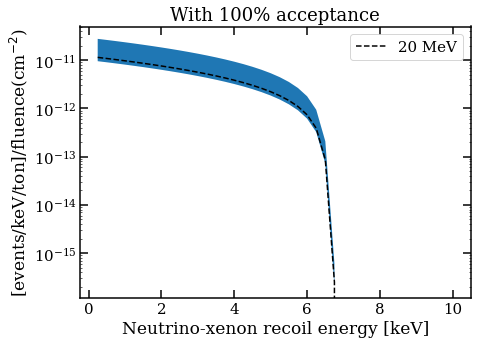

In [16]:
er = np.linspace(0.25, 10, 40)*keV
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])
tot_rate_low = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])*modification_low
tot_rate_up = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])*modification_up

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.semilogy(er / keV, tot_rate * ton / (keV**(-1)), 'k--', label="20 MeV")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)))
ax.legend()
ax.set_title("With 100% acceptance")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV/ton]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()



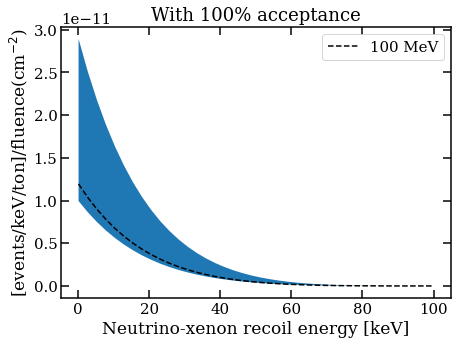

In [17]:
er = np.linspace(0.2, 100, 40)*keV
tot_rate = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) for x in er])
tot_rate_low = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) for x in er])*modification_low
tot_rate_up = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) for x in er])*modification_up

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.plot(er / keV, tot_rate * ton / (keV**(-1)), 'k--', label="100 MeV")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)))

ax.legend()
ax.set_title("With 100% acceptance")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV/ton]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

#  Acceptance

s2only_efficiency.csv is created using https://github.com/XENON1T/s2only/blob/master/analyses/total_efficiency.ipynb

where 'Energy' = d['es'] & 'Efficiency' = d['efficiency_nounc']

This efficiency includes reduction in fiducial target mass from 2.004 tonne.

In [19]:
Threshold_S2only = 0.7 # keV
Threshold_2fold = 1.6  #keV

In [20]:
acc_data = pd.read_csv('s2only_efficiency.csv').drop(columns='Unnamed: 0')
acc_data = acc_data[acc_data['Energy']>=Threshold_S2only].reset_index(drop=True)
accept = acc_data['Efficiency']*0.7 #because 30% of data is used for training
energy_S2only = acc_data['Energy'] * keV
accept_S2only = interp1d(energy_S2only, accept, bounds_error=False, fill_value=0, kind='linear')

In [21]:
acc_data = pd.read_csv('NR_acceptance_NSI_UL_200811.csv').drop(columns='Unnamed: 0')
acc_data = acc_data[acc_data['energy']>=Threshold_2fold].reset_index(drop=True)
accept = acc_data['acceptance']
energy_2fold = acc_data['energy'] * keV
accept_2fold = interp1d(energy_2fold, accept, bounds_error=False, fill_value=0, kind='linear')

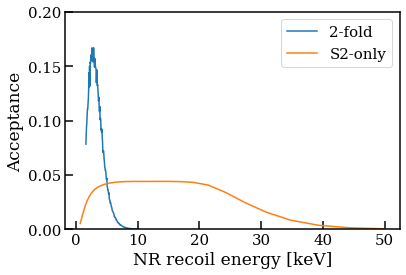

In [22]:
plt.plot(energy_2fold / keV, accept_2fold(energy_2fold), label="2-fold")
plt.plot(energy_S2only / keV, accept_S2only(energy_S2only), label="S2-only")
#plt.xlim(0, 50)
plt.ylim(0, 0.2)
plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.legend()
plt.show()

Acceptance for 3-fold is available at https://github.com/XENON1T/SR1Results/tree/master/Calibration/TemplateFiles/180420/run_combined_source_combined/acceptances

In [23]:
_3fold_min = 4.9 # keV
_3fold_max = 40.9 # keV

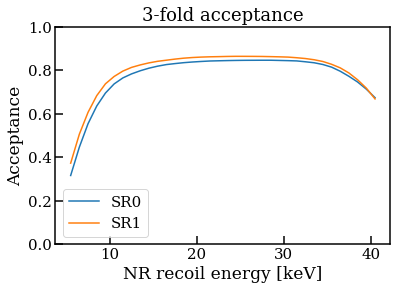

In [24]:
acceptanceFileNames = [
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr0', # SR0 WIMPs
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr1'  # SR1 WIMPs
]
percentiles = [pickle.load(open(af + '.pkl', 'rb')) for af in acceptanceFileNames]

energyEdges = percentiles[0]['energy_edges']
energy_3fold = (energyEdges[1:] + energyEdges[:-1]) / 2.


acc_data = pd.DataFrame(list(zip(energy_3fold, percentiles[0]['energy']['totalcombacc'].T[1], percentiles[1]['energy']['totalcombacc'].T[1]
)),
               columns =['energy', 'acceptance_SR0', 'acceptance_SR1'])

acc_data = acc_data[acc_data['energy']>=_3fold_min]
acc_data = acc_data[acc_data['energy']<=_3fold_max].reset_index(drop=True)

energy_3fold = acc_data['energy']*keV
accept_3fold_SR0 = interp1d(energy_3fold, acc_data["acceptance_SR0"], bounds_error=False, fill_value=0, kind='linear')
accept_3fold_SR1 = interp1d(energy_3fold, acc_data["acceptance_SR1"], bounds_error=False, fill_value=0, kind='linear')
plt.plot(energy_3fold / keV, accept_3fold_SR0(energy_3fold), label="SR0")
plt.plot(energy_3fold / keV, accept_3fold_SR1(energy_3fold), label="SR1")

plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.title("3-fold acceptance")
plt.ylim(0,1)
plt.legend()
plt.show()

# Events in 1 tonne detector at fixed Energy

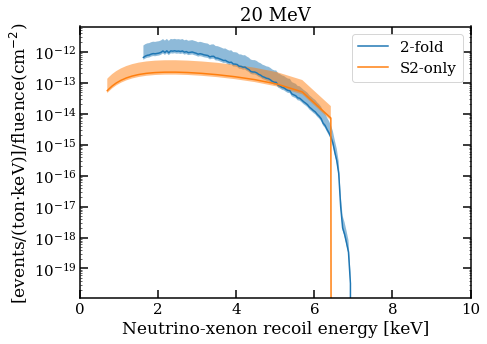

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

er = energy_2fold
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="2-fold")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

er = energy_S2only
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="S2-only")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)


ax.legend()
ax.set_title(r"20 MeV")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

The reason we see sharp decrease around 6.5 keV is because that corresponds to the maximum recoil energy for a neutrino energy of 20 MeV.

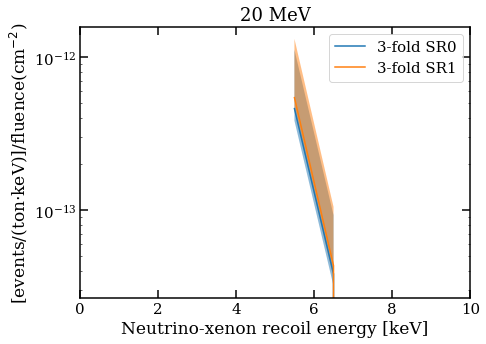

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

er = energy_3fold

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR0")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR1")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

ax.legend()
ax.set_title(r"20 MeV")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

# Events in detector at fixed Energy with desired fiducial mass

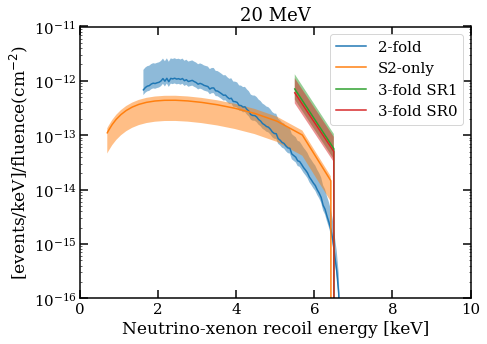

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

er = energy_2fold
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.04 * ton/ keV**(-1), label="2-fold")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

er = energy_S2only
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 2.004 * ton/ keV**(-1) , label="S2-only")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

er = energy_3fold
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR1")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR0")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)


ax.legend()
ax.set_title(r"20 MeV")
ax.set_ylim([1e-16, 1e-11])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

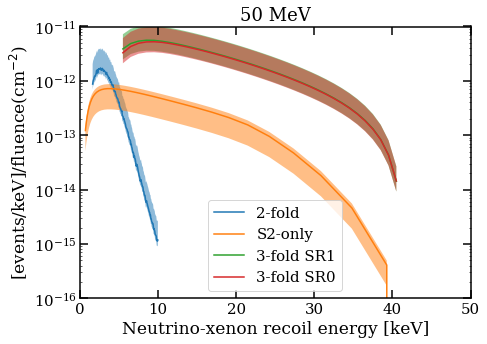

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

er = energy_2fold
tot_rate = np.array([sum([xe.dRatedErecoil(x, 50*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.04 * ton/ keV**(-1), label="2-fold")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

er = energy_S2only
tot_rate = np.array([sum([xe.dRatedErecoil(x, 50*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 2.004 * ton/ keV**(-1) , label="S2-only")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

er = energy_3fold
tot_rate = np.array([sum([xe.dRatedErecoil(x, 50*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR1")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 50*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR0")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)


ax.legend()
ax.set_title(r"50 MeV")
ax.set_ylim([1e-16, 1e-11])
ax.set_xlim([0, 50])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

In [51]:
#Checking if integration (area under curve) gives reasonable values:
'''    
total_rate = 0
for i in range(0,np.shape(energy_S2only)[0]-1):
    er = (energy_S2only[i]+energy_S2only[i+1])/2
    delta_energy = energy_S2only[i+1] - energy_S2only[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_S2only(er)
    total_rate = total_rate + rate * delta_energy * 2.004 * ton
print(total_rate)

total_rate = 0
for i in range(0,np.shape(energy_2fold)[0]-1):
    er = (energy_2fold[i]+energy_2fold[i+1])/2
    delta_energy = energy_2fold[i+1] - energy_2fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_2fold(er)
    total_rate = total_rate + rate * delta_energy * 1.04 * ton
print(total_rate)

total_rate = 0
for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
print(total_rate)

total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
print(total_rate)
'''

Ignore


# Events in detector for neutrino energies

In [29]:
Neutrino_Energy = np.linspace(5, 100, 191)*MeV

def calc_rate_Ev(energy, accept, fm):
    total_rate_Ev = []
    for Ev in Neutrino_Energy:
        total_rate = 0
        for i in range(0,np.shape(energy)[0]-1):
            er = (energy[i]+energy[i+1])/2
            delta_energy = energy[i+1] - energy[i]
            rate = sum([xe.dRatedErecoil(er, Ev) for xe in NaturalXe]) * accept(er)
            total_rate = total_rate + rate * delta_energy * fm * ton
        total_rate_Ev.append(total_rate)
    return(np.array(total_rate_Ev))

In [30]:
fm_3fold = 1.3
fm_2fold = 1.04 
fm_S2only = 2.004 #used in https://github.com/XENON1T/s2only/blob/master/analyses/total_efficiency.ipynb to calculate exposure

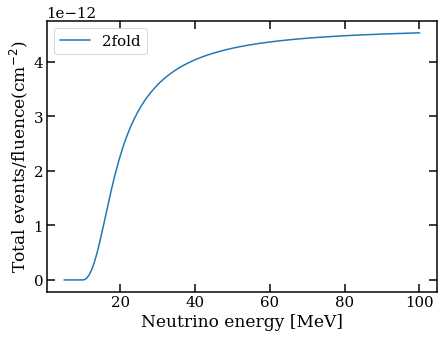

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_2fold, accept_2fold, fm_2fold), label="2fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

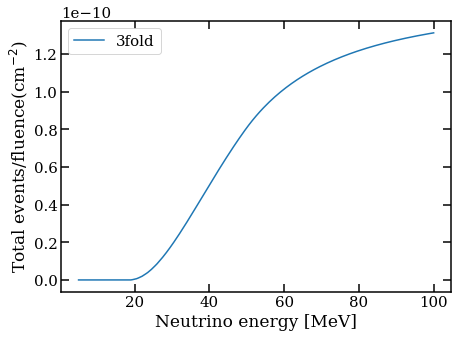

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_3fold, accept_3fold_SR1, fm_3fold), label="3fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

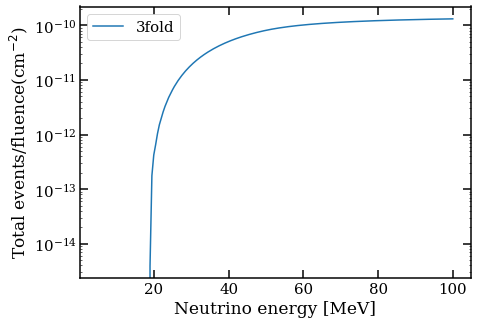

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_3fold, accept_3fold_SR1, fm_3fold), label="3fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
plt.yscale("log")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

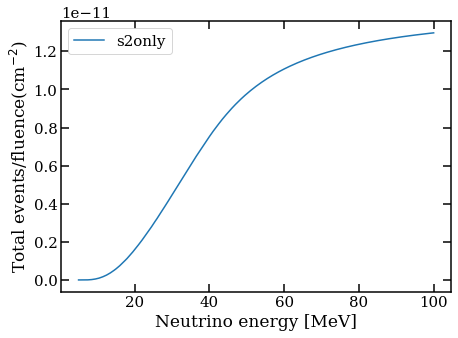

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_S2only, accept_S2only, fm_S2only), label="s2only")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

In [35]:
rate_Ev_2fold = calc_rate_Ev(energy_2fold, accept_2fold, fm_2fold)
rate_Ev_3fold = calc_rate_Ev(energy_3fold, accept_3fold_SR1, fm_3fold)
rate_Ev_S2only = calc_rate_Ev(energy_S2only, accept_S2only, fm_S2only)

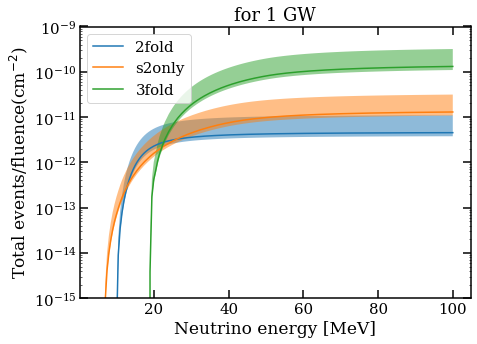

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, rate_Ev_2fold, label="2fold")
plt.fill_between(Neutrino_Energy/MeV, rate_Ev_2fold*modification_low, rate_Ev_2fold*modification_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, rate_Ev_S2only, label="s2only")
plt.fill_between(Neutrino_Energy/MeV, rate_Ev_S2only*modification_low, rate_Ev_S2only*modification_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, rate_Ev_3fold, label="3fold")
plt.fill_between(Neutrino_Energy/MeV, rate_Ev_3fold*modification_low, rate_Ev_3fold*modification_up, alpha = 0.5)

#ax.legend()
ax.set_title("for 1 GW")
ax.set_ylim([1e-15, 1e-9])
#ax.set_xlim([0, 5])
plt.yscale("log")

ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

# Set constraints

We have only one observation point for neutron star mergers - GW170817

In [37]:
upper_lim_fluence_2_fold = 2.3/(rate_Ev_2fold)
upper_lim_fluence_2_fold_low = 2.3/(rate_Ev_2fold*modification_low)
upper_lim_fluence_2_fold_up = 2.3/(rate_Ev_2fold*modification_up)

upper_lim_fluence_3_fold = 2.3/(rate_Ev_3fold)
upper_lim_fluence_3_fold_low = 2.3/(rate_Ev_3fold*modification_low)
upper_lim_fluence_3_fold_up = 2.3/(rate_Ev_3fold*modification_up)

upper_lim_fluence_S2only = 2.3/(rate_Ev_S2only)
upper_lim_fluence_S2only_low = 2.3/(rate_Ev_S2only*modification_low)
upper_lim_fluence_S2only_up = 2.3/(rate_Ev_S2only*modification_up)

<ipython-input-37-50f37f936a05>:1: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_2_fold = 2.3/(rate_Ev_2fold)
<ipython-input-37-50f37f936a05>:2: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_2_fold_low = 2.3/(rate_Ev_2fold*modification_low)
<ipython-input-37-50f37f936a05>:3: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_2_fold_up = 2.3/(rate_Ev_2fold*modification_up)
<ipython-input-37-50f37f936a05>:5: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold = 2.3/(rate_Ev_3fold)
<ipython-input-37-50f37f936a05>:6: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold_low = 2.3/(rate_Ev_3fold*modification_low)
<ipython-input-37-50f37f936a05>:7: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold_up = 2.3/(rate_Ev_3fold*modification_up)
<ipython-input-37-50f37f936a05>:9: RuntimeWarning: divide by zero en

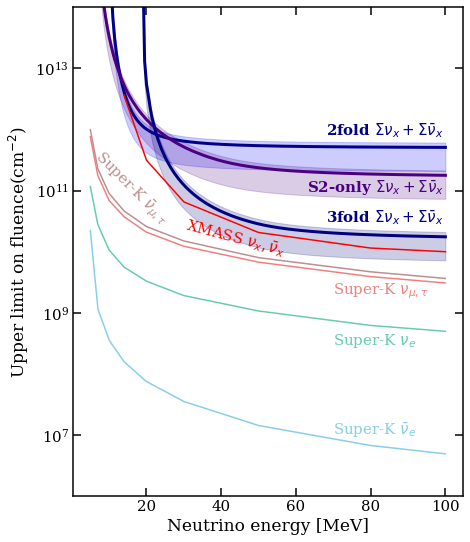

In [38]:
Anti_neutrinio_x = pd.read_csv('Anti_neutrino_x.csv')
neutrinio_x = pd.read_csv('neutrino_x.csv')
Anti_neutrinio_e = pd.read_csv('anti_neutrino_e.csv')
neutrinio_e = pd.read_csv('neutrino_e.csv')
XMASS_neutrinio = pd.read_csv('XMASS_neutrino.csv')

fig, ax = plt.subplots(1, 1, figsize=(7,9))


plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_2_fold, color="darkblue",  linewidth = 3, label=r"2fold ${\nu}_x, \bar{\nu}_x$")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_2_fold_low, upper_lim_fluence_2_fold_up, color="blue", alpha = 0.2)
plt.text(68, 8*1e11, r"2fold $\Sigma {\nu}_x + \Sigma\bar{\nu}_x$", weight='bold', color="darkblue")

plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_S2only, color="indigo",  linewidth = 3, label=r"S2only ${\nu}_x, \bar{\nu}_x$")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_S2only_low, upper_lim_fluence_S2only_up, color="indigo", alpha = 0.2)
plt.text(63, 9*1e10, r"S2-only $\Sigma {\nu}_x + \Sigma\bar{\nu}_x$", weight='bold', color="indigo")

plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_3_fold, color="navy",  linewidth = 3, label=r"3fold ${\nu}_x, \bar{\nu}_x$")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_3_fold_low, upper_lim_fluence_3_fold_up, color="navy", alpha = 0.2)
plt.text(68, 3*1e10, r"3fold $\Sigma {\nu}_x + \Sigma\bar{\nu}_x$", weight='bold', color="navy")

plt.plot(XMASS_neutrinio['Energy'], XMASS_neutrinio['fluence'], color="red", label=r"XMASS ${\nu}_x, \bar{\nu}_x$")
plt.text(30, 8.5*1e9, r"XMASS ${\nu}_x, \bar{\nu}_x$", color="red", rotation = -15)

plt.plot(Anti_neutrinio_x['Energy'], Anti_neutrinio_x['fluence'], color="rosybrown", label=r"Super-K $\bar{\nu}_{\mu,\tau}$")
plt.text(5, 3*1e10, r"Super-K $\bar{\nu}_{\mu,\tau}$", color="rosybrown", rotation = -45)

plt.plot(neutrinio_x['Energy'], neutrinio_x['fluence'], label=r"Super-K ${\nu}_{\mu,\tau}$", color="lightcoral")
plt.text(70, 2*1e9, r"Super-K ${\nu}_{\mu,\tau}$", color="lightcoral")

plt.plot(neutrinio_e['Energy'], neutrinio_e['fluence'], label=r"Super-K ${\nu}_e$", color="mediumaquamarine")
plt.text(70, 3*1e8, r"Super-K ${\nu}_e$", color="mediumaquamarine")

plt.plot(Anti_neutrinio_e['Energy'], Anti_neutrinio_e['fluence'], label=r"Super-K $\bar{\nu}_e$", color="skyblue")
plt.text(70, 1e7, r"Super-K $\bar{\nu}_e$", color="skyblue")

#ax.set_title(r"(Total events/flux ")
ax.set_ylim([1e6, 1e14])
plt.yscale("log")
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
#plt.title("NS-NS merger")

plt.show()

For 30 Gev/c^2 dark matter limits on dark matter cross-section (in cm^2):

3-fold -> 4.5 * 10^-46

S2-only -> 4.5 * 10^-45

i.e. an order magnitude worse. Matches with our limits.

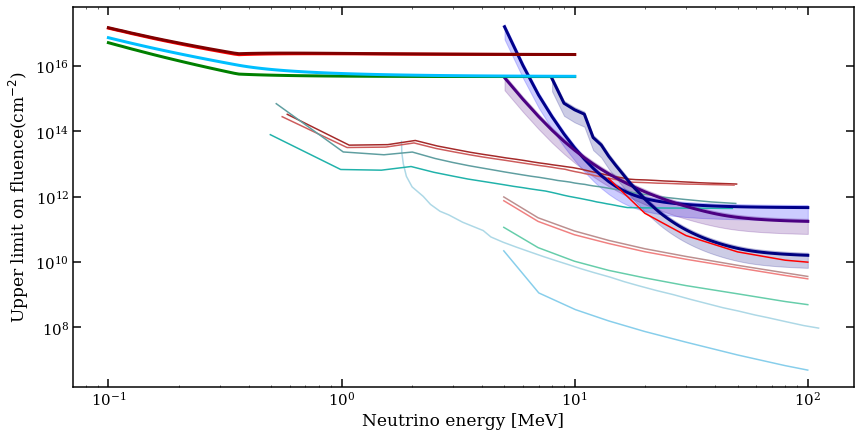

In [123]:
'''
Anti_neutrinio_x = pd.read_csv('Anti_neutrino_x.csv')
neutrinio_x = pd.read_csv('neutrino_x.csv')
Anti_neutrinio_e = pd.read_csv('anti_neutrino_e.csv')
neutrinio_e = pd.read_csv('neutrino_e.csv')
XMASS_neutrinio = pd.read_csv('XMASS_neutrino.csv')
Kamland = pd.read_csv('Kamland_e.csv')

Borexino_anti_neutrinio_e = pd.read_csv('Borexino_anti_neutrino_e.csv')
Borexino_neutrinio_e = pd.read_csv('Borexino_neutrino_e.csv')
Borexino_anti_neutrinio_x = pd.read_csv('Borexino_anti_neutrino_x.csv')
Borexino_neutrinio_x = pd.read_csv('Borexino_neutrino_x.csv')

ER_limits = pd.read_csv("ER_limits.csv") #generated using https://github.com/XENON1T/Gravitational-Waves/blob/master/CC-interaction%2Bneutrino%2Blimit.ipynb

fig, ax = plt.subplots(1, 1, figsize=(14,7))
plt.plot(Kamland['Energy'], Kamland['fluence'], color="lightblue", label=r"Super-K $\bar{\nu}_e$")
plt.plot(Borexino_anti_neutrinio_x['Energy'], Borexino_anti_neutrinio_x['fluence'], color="brown")
plt.plot(Borexino_neutrinio_x['Energy'], Borexino_neutrinio_x['fluence'], color="indianred")
plt.plot(Borexino_anti_neutrinio_e['Energy'], Borexino_anti_neutrinio_e['fluence'], color="cadetblue")
plt.plot(Borexino_neutrinio_e['Energy'], Borexino_neutrinio_e['fluence'], color="lightseagreen")

plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_2_fold, color="darkblue",  linewidth = 3, label=r"2fold ${\nu}_x, \bar{\nu}_x$")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_2_fold_low, upper_lim_fluence_2_fold_up, color="blue", alpha = 0.2)
#plt.text(68, 8*1e11, r"2fold $\Sigma {\nu}_x + \Sigma\bar{\nu}_x$", weight='bold', color="blue")

plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_S2only, color="indigo",  linewidth = 3, label=r"S2only ${\nu}_x, \bar{\nu}_x$")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_S2only_low, upper_lim_fluence_S2only_up, color="indigo", alpha = 0.2)
#plt.text(63, 9*1e10, r"S2-only $\Sigma {\nu}_x + \Sigma\bar{\nu}_x$", weight='bold', color="indigo")

plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_3_fold, color="navy",  linewidth = 3, label=r"3fold ${\nu}_x, \bar{\nu}_x$")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_3_fold_low, upper_lim_fluence_3_fold_up, color="navy", alpha = 0.2)
#plt.text(68, 3*1e10, r"3fold $\Sigma {\nu}_x + \Sigma\bar{\nu}_x$", weight='bold', color="navy")

plt.plot(XMASS_neutrinio['Energy'], XMASS_neutrinio['fluence'], color="red", label=r"XMASS ${\nu}_x, \bar{\nu}_x$")
#plt.text(65, 4.5*1e9, r"XMASS $\Sigma {\nu}_x + \Sigma\bar{\nu}_x$", color="red", rotation = -5)

plt.plot(Anti_neutrinio_x['Energy'], Anti_neutrinio_x['fluence'], color="rosybrown", label=r"Super-K $\bar{\nu}_{\mu,\tau}$")

plt.plot(neutrinio_x['Energy'], neutrinio_x['fluence'], label=r"Super-K ${\nu}_{\mu,\tau}$", color="lightcoral")

plt.plot(neutrinio_e['Energy'], neutrinio_e['fluence'], label=r"Super-K ${\nu}_e$", color="mediumaquamarine")

plt.plot(Anti_neutrinio_e['Energy'], Anti_neutrinio_e['fluence'], label=r"Super-K $\bar{\nu}_e$", color="skyblue")

plt.plot(ER_limits['Energy'], ER_limits['ul_nu_e'], linewidth=3, color="green")
plt.plot(ER_limits['Energy'], ER_limits['ul_nu_mu_tau'], linewidth=3, color="red")
plt.plot(ER_limits['Energy'], ER_limits['ul_anti_nu_e'], linewidth=3, color="deepskyblue")
plt.plot(ER_limits['Energy'], ER_limits['ul_anti_nu_mu_tau'], linewidth=3, color="maroon")
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e6, 1e16])
plt.yscale("log")
plt.xscale("log")

#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
#plt.title("NS-NS merger")

plt.show()
'''

In [41]:
'''
Mpc = 3.0857*10**22 #m
distance_merger = 40 * Mpc * 100 #cm #for GW170817
#Lets see 0.5 MeV neutrinos
N_emitted = 5.3*10**15*(4* 3.14 * distance_merger)**2
E_emitted = N_emitted * 0.5*10**6 * 1.6*10**(-19) #Joule
E_emitted 
10**57 /(1.6*10**(-10))/ solar_mass
'''
print("Ignore")

Ignore


# Sanity Checks - 80 MeV Neutrinos

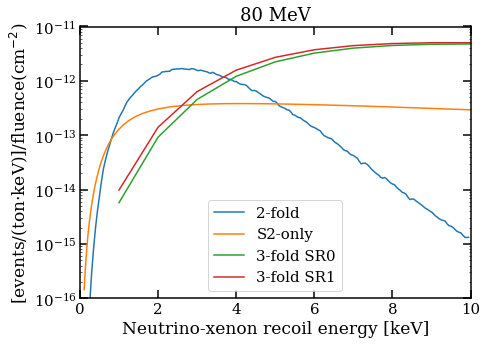

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))


er = []
for i in range(0,np.shape(energy_2fold)[0]-1):
    er.append((energy_2fold[i]+energy_2fold[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="2-fold")


er = []
for i in range(0,np.shape(energy_S2only)[0]-1):
    er.append((energy_S2only[i]+energy_S2only[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="S2-only")

er = []
for i in range(0,np.shape(energy_3fold)[0]-1):
    er.append((energy_3fold[i]+energy_3fold[i+1])/2)
er=np.array(er)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR0")

tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR1")

ax.legend()
ax.set_title(r"80 MeV")
ax.set_ylim([1e-16, 1e-11])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

In [36]:
total_rate = 0
for i in range(0,np.shape(energy_S2only)[0]-1):
    er = (energy_S2only[i]+energy_S2only[i+1])/2
    delta_energy = energy_S2only[i+1] - energy_S2only[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_S2only(er)
    total_rate = total_rate + rate * delta_energy * 2.004 * ton
total_rate

1.2390942667886128e-11

In [37]:
total_rate = 0
for i in range(0,np.shape(energy_2fold)[0]-1):
    er = (energy_2fold[i]+energy_2fold[i+1])/2
    delta_energy = energy_2fold[i+1] - energy_2fold[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_2fold(er)
    total_rate = total_rate + rate * delta_energy * 1.04 * ton
total_rate

4.85843435610784e-12

In [38]:
total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR1(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
total_rate

1.3156777279577983e-10

# Axion limits

In [42]:
N_T

4.588020143230578e+27

In [43]:
efficiency_ER = 0.89 #figure 2 of https://arxiv.org/pdf/2006.09721.pdf

In [44]:
N_T * efficiency_ER 

4.0833379274752144e+27

In [45]:
UL_K_times_sigma = 2.3/(N_T * efficiency_ER)
UL_K_times_sigma

5.632646723956355e-28

In [46]:
cross_section = np.logspace(-48,-24,13) 
cross_section

array([1.e-48, 1.e-46, 1.e-44, 1.e-42, 1.e-40, 1.e-38, 1.e-36, 1.e-34,
       1.e-32, 1.e-30, 1.e-28, 1.e-26, 1.e-24])

In [47]:
Fluence = UL_K_times_sigma/cross_section
Fluence

array([5.63264672e+20, 5.63264672e+18, 5.63264672e+16, 5.63264672e+14,
       5.63264672e+12, 5.63264672e+10, 5.63264672e+08, 5.63264672e+06,
       5.63264672e+04, 5.63264672e+02, 5.63264672e+00, 5.63264672e-02,
       5.63264672e-04])

In [48]:
np.size(Fluence)

13

In [49]:
Mpc = 3.0857*10**22 #m
distance_merger = 40 * Mpc * 100 #cm #for GW170817
solar_mass = 2 * 10**30 * kg #GeV
M_merger = 2.82 * solar_mass /keV #keV
radiated_GW_energy = 0.025 * solar_mass /keV 
#https://www.ligo.caltech.edu/system/avm_image_sqls/binaries/99/original/GW170817_Factsheet.jpg?1508114118

In [50]:
#assuming 10 keV axions
Max_fluence_axion = M_merger/(10*(4* 3.14 * distance_merger)**2)
np.log10(Max_fluence_axion)

8.119403457205157

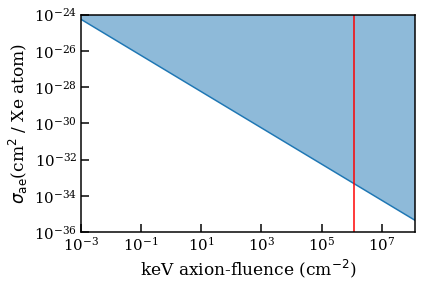

In [51]:
plt.plot(Fluence, cross_section)
plt.fill_between(Fluence, cross_section, np.ones(np.size(Fluence))*1e-24, alpha = 0.5)
plt.xlabel(r"keV axion-fluence (cm$^{-2}$)")
plt.ylabel(r"$\sigma_\mathrm{ae}$(cm$^2$ / Xe atom)")
plt.ylim(1e-36,1e-24)
plt.xlim(1e-3,Max_fluence_axion)
plt.axvline(radiated_GW_energy/(10*(4* 3.14 * distance_merger)**2), color="r")
plt.xscale('log')
plt.yscale('log')
plt.show()